In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
from google.colab import drive
import matplotlib.pyplot as plt
import torch.nn as nn
import torch
from torch.utils.data import Dataset, DataLoader
from tqdm.auto  import tqdm
import os

In [ ]:
drive.mount("/content/drive")
print("Drive Mounted")
os.makedirs('/content/drive/MyDrive/RNN/Forecast/',exist_ok=True)
print("Folder Created")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive Mounted
Folder Created


In [ ]:

url="https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv"
df=pd.read_csv(url)
df=df.drop_duplicates()
df=df.sort_values("Date").set_index("Date")
print(len(df))
df.head()

3650


,Temp
Date,
1981-01-01,20.7
1981-01-02,17.9
1981-01-03,18.8
1981-01-04,14.6
1981-01-05,15.8


<Figure size 4000x4400 with 0 Axes>

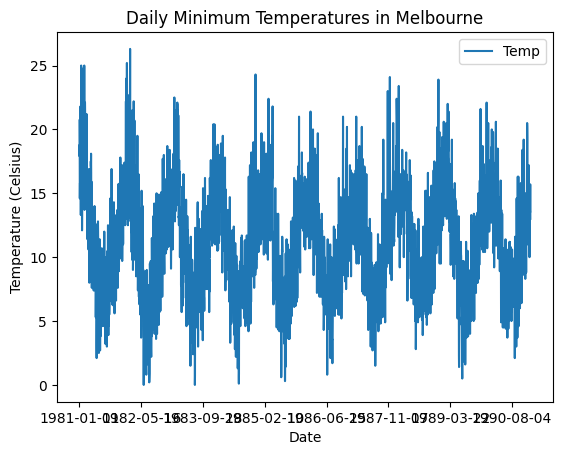

In [ ]:
plt.figure(figsize=(20,22), dpi=200)
df["1981-01":].plot()
plt.title("Daily Minimum Temperatures in Melbourne")
plt.xlabel("Date")
plt.ylabel("Temperature (Celsius)")
plt.show()

In [ ]:
class TimeSeriesDataset(Dataset):
    def __init__(self,data,window_size):
        super().__init__()
        self.data=data
        self.window_size=window_size
    def __len__(self):
        return len(self.data)-self.window_size
    def __getitem__(self, index):
        x=self.data[index:index+self.window_size]
        y=self.data[index+1:index+self.window_size+1]
        return torch.tensor(x,dtype=torch.float32),torch.tensor(y,dtype=torch.float32)

In [ ]:
training_data=TimeSeriesDataset(df["Temp"].values[:2920],50)
test_data=TimeSeriesDataset(df["Temp"].values[2920:],50)
train_dataloader=DataLoader(training_data,batch_size=64,shuffle=True)
test_dataloader=DataLoader(test_data,batch_size=64,shuffle=False)

In [ ]:
for x,y in train_dataloader:
    temp=x  
    print(y.size())
    break

torch.Size([64, 50])


In [ ]:
class RNN(nn.Module):
    def __init__(self,input_size,output_size=1,hidden_size=20,num_layers=3):
        super().__init__()
        self.RNN=nn.RNN(input_size,hidden_size,num_layers,batch_first=True)
        self.Linear=nn.Linear(hidden_size,output_size)
    def forward(self,x):
        out,_=self.RNN(x)
        out=self.Linear(out)
        return out.squeeze(-1)

In [ ]:
torch.manual_seed(0)
model=RNN(1)


In [ ]:
optimizer=torch.optim.SGD(model.parameters(),lr=0.01)
loss_fn=nn.MSELoss()

In [ ]:
#checkpoint=torch.load("/content/drive/MyDrive/RNN/Forecast/checkpoint.pth")
#model.load_state_dict(checkpoint["model_state_dict"])
#optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
#_epochs=checkpoint["epoch"]
#losses=checkpoint["loss"]

In [ ]:
epoch=120
losses=[]
epochs=[]
for i in tqdm(range(_epochs,epoch)):
    model.train()
    epoch_loss=0
    for x,y in train_dataloader:
        optimizer.zero_grad()
        out=model(x.unsqueeze(-1))
        loss=loss_fn(out,y)
        loss.backward()
        optimizer.step()
        epoch_loss+=loss.item()
    losses.append(epoch_loss/len(train_dataloader))
    epochs.append(i)
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': epoch_loss/len(train_dataloader),
    },"/content/drive/MyDrive/RNN/Forecast/checkpoint.pth")

0it [00:00, ?it/s]

In [ ]:
len(epochs),len(losses)

(0, 0)

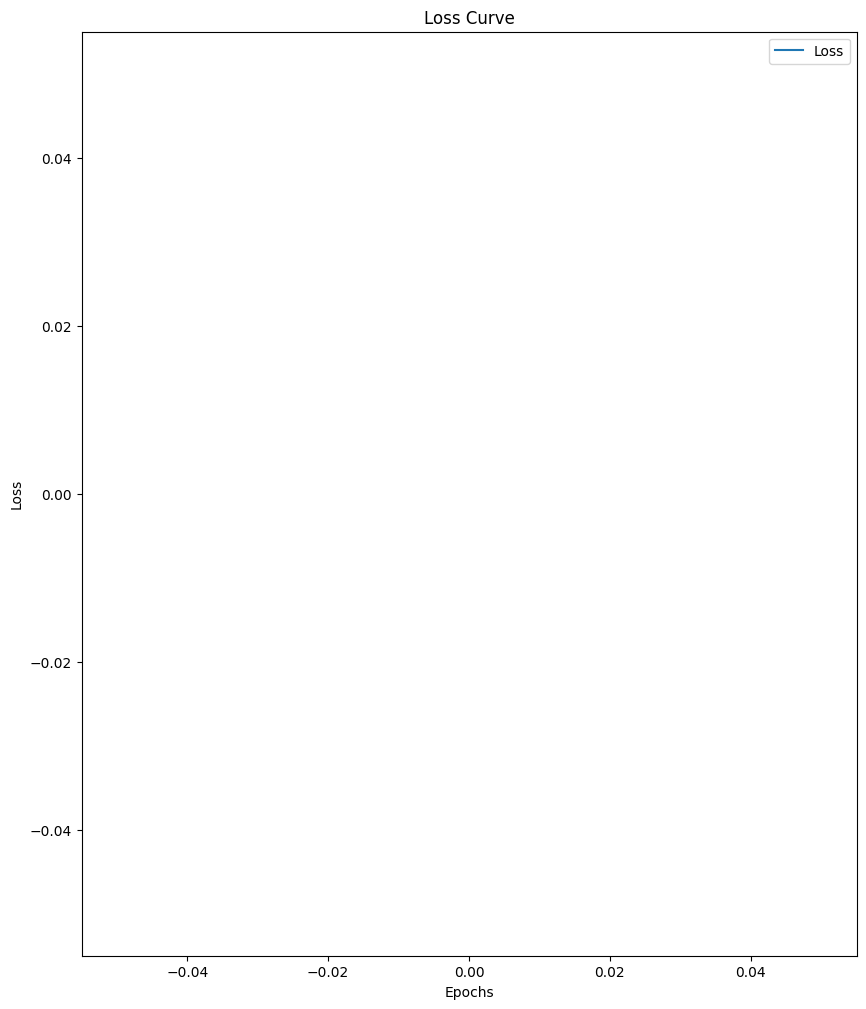

In [ ]:
plt.figure(figsize=(10,12))
plt.plot(epochs,losses,label="Loss")
plt.title("Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [ ]:
model.eval()
losses=[]
trials=[]
count=0
x_both=[]
y_pred=[]
y_target=[]
with torch.inference_mode():
    for x,y in test_dataloader:
        count+=1
        out=model(x.unsqueeze(-1))
        loss_x=loss_fn(out,y)
        losses.append(loss_x.item())
        x_both.extend(x.tolist())
        y_pred.extend(out[:,-1])
        y_target.extend(y[:,-1])
        trials.append(count)
    print(f"Test Loss: {np.mean(losses)}")
    

Test Loss: 135.65746654163706


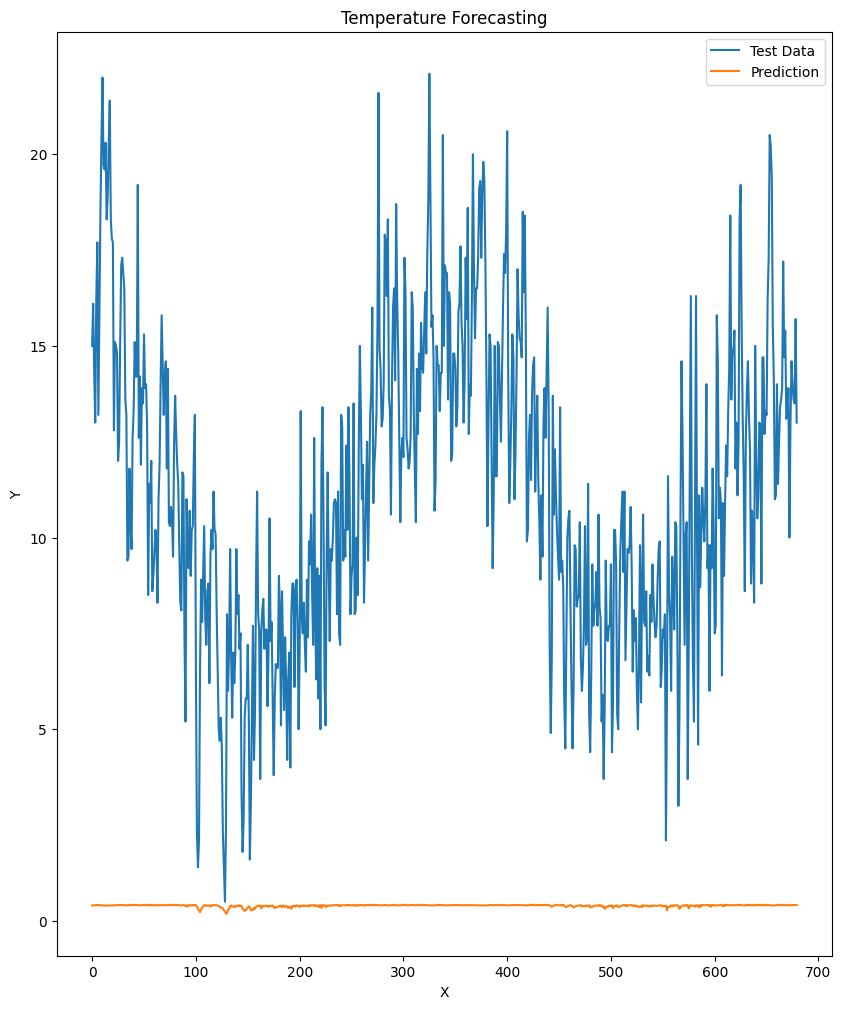

In [ ]:
indices=range(len(y_target))
plt.figure(figsize=(10,12), dpi=100)
plt.plot(indices,y_target,label="Test Data")
plt.plot(indices,y_pred,label="Prediction")
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Temperature Forecasting")
plt.legend()
plt.show()